# Data Pipeline Project — Overview

> **Purpose:** This notebook documents the full architecture, workflow, and implementation requirements for our collaborative data pipeline project. It is intended to contain all of the reference information necessary to create your own pipeline using our stack architecture.
>
---

## Section 1 — Project Overview

### 1.1 What We Have Built

We built an **end-to-end, fully online data pipeline** that:

1. Downloads data from a public REST API
2. Cleans and normalizes that data using a set of modular cleaning functions
3. Stores cleaned data as CSV files with meaningful date-range names
4. Loads data into a structured relational database that eliminates redundancy
5. Serves a live web dashboard for visualization and read-only querying
6. Runs on an automated schedule to pull in new data without manual intervention


---

### 1.2 Services and Tools

| Layer | Service | Purpose |
|---|---|---|
| **Version control** | GitHub | Stores all code; triggers deployments and scheduled jobs |
| **Raw + cleaned data storage** | Supabase Storage (buckets) | Holds intermediate CSV files accessible to all scripts |
| **Relational database** | Supabase PostgreSQL | Final normalized database; queried by the dashboard |
| **Scheduled automation** | GitHub Actions | Runs the incremental fetch → clean → port pipeline on a cron schedule |
| **Dashboard hosting** | Streamlit Community Cloud | Auto-deploys the dashboard from GitHub; queries Supabase live |



---

### 1.3 Repository Structure

```
project-repo/
│
├── fetch_data.py           # Fetches either full historical dataset (if Supabase tables are empty) or just the most recent data
│
├── clean_data.py           # Reads raw CSV → applies cleaning functions → saves cleaned CSV
├── cleaning/
│   ├── __init__.py
│   ├── normalize_caps.py   # One cleaning concern per file
│   ├── strip_whitespace.py
│   ├── parse_dates.py
│   └── ... (one file per cleaning function)
│
├── setup_db.py             # One-time: creates schema in Supabase
├── port_data.py            # Loads cleaned CSV into the database (with dedup)
│
├── streamlit_app.py        # Dashboard: visualizations + read-only queries
│
├── local_deploy/           # Local Dashboard option: local PostgreSQL volume + local app
│   ├── app/                # Identical looking app, slighty different query
|   │   ├── streamlit_app.py
│   │   ├── wait_for_db.py
│   │   ├── requirements.txt
│   │   └── Dockerfile
│   ├── etl                 # Extracts data directly from Supabase to cache in local volume
│   │   ├── sync_supabase.py
│   │   ├── requirements.txt
│   │   └── Dockerfile
│   ├── .env
│   └── docker-compose.yml  # docker compose up --build to orchestrate whole local app
│
├── .github/
│   └── workflows/
│       └── update_pipeline.yml   # GitHub Actions cron workflow
│
├── requirements.txt
├── .env
├── project_overview.ipynb
└── README.md
```

---

### 1.4 Full Pipeline Workflow

The pipeline has two modes: **initial setup** (run once) and **scheduled updates** (run automatically).

**Initial setup sequence (manual, run once):**
```
fetch_data.py  →  clean_data.py  →  setup_db.py  →  port_data.py
```

**Scheduled update sequence (automated via GitHub Actions):**
```
fetch_data.py  →  clean_data.py  →  port_data.py
```

The dashboard (`streamlit_app.py`) runs continuously on Streamlit Community Cloud and always reflects the current state of the database.

---

### 1.5 Data Flow Summary

```
REST API
   │
   ▼
fetch_data.py
   │  saves  raw/YYYY-MM-DD_YYYY-MM-DD.csv
   ▼
Supabase Storage  (raw bucket)
   │
   ▼
clean_data.py
   │  saves  cleaned/YYYY-MM-DD_YYYY-MM-DD.csv
   ▼
Supabase Storage  (cleaned bucket)
   │
   ▼
port_data.py  (INSERT ... ON CONFLICT DO NOTHING)
   │
   ▼
Supabase PostgreSQL  (normalized tables)
   │
   ▼
streamlit_app.py  →  Streamlit Community Cloud  →  Users
```

---
## Section 2 — Fetching Raw Data from the API

### 2.1 How the REST API Works

A REST API exposes data over HTTP. You send a `GET` request to a URL (the **endpoint**) with optional **query parameters** that filter or paginate the results. The API responds with data — typically in JSON format — which we then parse and save.

Key concepts relevant to our pipeline:

- **Endpoint:** The base URL for the data resource (e.g., `https://data.cityofnewyork.us/resource/43nn-pn8j.json`)
- **Query parameters:** Filters appended to the URL (e.g., `?since=2024-01-01&limit=1000`)
- **Pagination:** Most APIs do not return all records in one response. They return a page of results plus a cursor or page number to request the next page. We must loop until all pages are retrieved.
- **Rate limiting:** APIs typically cap how many requests you can make per minute. We must respect this with `time.sleep()` calls between requests.
- **Authentication:** Most APIs require an API key passed as a header (e.g., `Authorization: Bearer <key>`) or query parameter. Keys must be stored as GitHub Secrets — never hardcoded in source files. Our API is open source, but we used an API Token to remove API rate limits.

---

### 2.2 `fetch_all.py` — Full Historical Fetch

**Purpose:** Download the complete history of data from the API. This script is run **once** during initial setup (and again if the database ever needs to be rebuilt from scratch). This same script is also ran during scheduled API requests to fetch new data.

**Key requirements:**

- **Batch by date range.** Rather than fetching everything in one giant request, the script divides time into fixed windows (e.g., monthly or quarterly batches) and fetches one window at a time.
- **New data pulling.** The script accesses the Supabase directly to find the last inserted entry date (inspection_data column), then attempts to fetch data only after that data. If the Supabase table is empty, it will default to fetching all of the data from the API in batched batches.
- **Resume on failure.** The script tracks progress in a small state file (`fetch_progress.json` in Supabase Storage or locally). If the script crashes at batch 47 of 200, re-running it picks up at batch 47 instead of starting over.
- **Save each batch as a CSV.** Each batch is saved as `raw/YYYY-MM-DD_YYYY-MM-DD.csv` in Supabase Storage, where the dates reflect the *data's date range*, not the date the script ran.
- **Log every batch.** Print (or log to a file) which date range was fetched, how many records were returned, and whether the save succeeded.

---
## Section 3 — Cleaning the Data

### 3.1 Design Philosophy

Each cleaning operation is implemented as its own **small, focused function** in its own file inside the `cleaning/` package. This design:

- Makes each function easy to test in isolation
- Makes it easy to turn individual cleaning steps on or off
- Makes the pipeline readable — `clean_data.py` reads like a checklist
- Avoids one giant function that is hard to debug


Every cleaning function must follow this contract:

```python
def clean_<something>(df: pd.DataFrame) -> pd.DataFrame:
    """One-line description of what this function does."""
    # ... transformation ...
    return df
```

Functions take a DataFrame and return a DataFrame. They do not modify the input in place.

---

### 3.2 Cleaning Functions

The cleaning scripts can be found in the cleaning folder. Each script does a small cleaning task. If attempting to use a different API (and this dataset), the cleaning functions will not work. These scripts generally contain hard-coded information directly relevant to the API used. For example, the cleaning script `infer_grades.py` directly references the 'score' column in the CSV files in order to infer the grade the restaurant was/will be given.

---

### 3.3 `clean_data.py` — The Orchestrator

This script reads a raw CSV from Supabase Storage, applies all cleaning functions in sequence, and saves the result as a cleaned CSV. It is called with a filename argument so the same script works for any batch.

**Key requirements:**
- Read all candidate files directly from the Supabase raw bucket and decide which ones are new and must be cleaned.
- Log the row count before and after cleaning so we can detect unexpected data loss.
- Save the cleaned CSV to the `cleaned/` bucket in Supabase Storage with the **same filename** as the raw CSV (just in a different bucket/folder).

---
## Section 4 — Database Design

### 4.1 Design Goals

The database schema must satisfy three properties:

1. **No redundancy (normalization).** The same piece of information should be stored in exactly one place. For example, if a record references a city, the city's metadata (population, state, etc.) should be in its own table — not repeated on every record.
2. **Data integrity.** Foreign key constraints, NOT NULL constraints, and unique constraints should be used to prevent invalid data from entering the database.
3. **Queryability.** The schema should make common dashboard queries fast and simple — avoid deeply nested structures that require many joins.

---

### 4.2 Normalization (Plain English)

Normalization means splitting data into tables so that each fact is stored exactly once. The standard levels are:

- **1NF:** Each cell contains one value (no comma-separated lists inside a cell).
- **2NF:** Each non-key column depends on the *whole* primary key, not just part of it.
- **3NF:** No column depends on another non-key column (no transitive dependencies).

For our project, we target **3NF**. In practice this means: if two records share the same category, location, or entity, that shared data lives in a lookup table with a foreign key — not duplicated on every row.

---

### 4.3 Schema Design

This is the exact table schema design used for our data in Supabase:

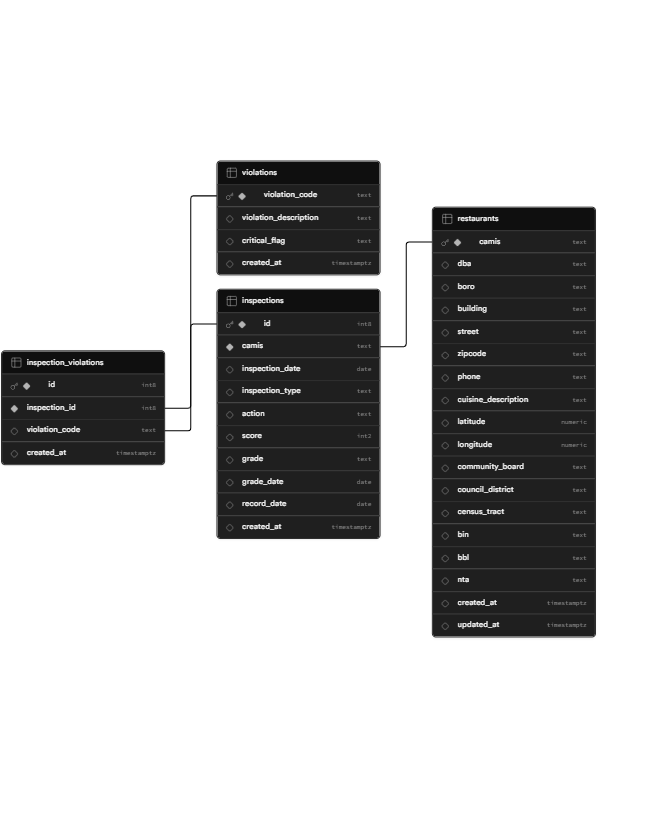

### 4.4 `setup_db.py` — Schema Creation

**Purpose:** Connect to Supabase and run the SQL commands that create all tables, indexes, and constraints. This script is run **once** during initial setup.

**Key requirements:**
- Use `CREATE TABLE IF NOT EXISTS` so the script is safely re-runnable without destroying existing data.
- Define all foreign key constraints at creation time.
- Add a `UNIQUE` constraint on the API's native record ID column — this is what enables the deduplication `ON CONFLICT` clause in `port_data.py`.

---
## Section 5 — Porting Data into the Database

### 5.1 Overview

`port_data.py` reads a cleaned CSV from Supabase Storage and inserts its rows into the normalized PostgreSQL tables. It is called both during initial setup (after `fetch_data.py` + `clean_data.py`) and during every scheduled update.

---

### 5.2 Deduplication Strategy

Even though `fetch_data.py` only requests new data if the table is populated, duplicates can still appear in edge cases:

- The API's `since=` filter might use inclusive boundaries, returning one already-seen record
- A GitHub Actions run might be retried after a partial failure
- The same CSV might be manually re-ported during debugging

We guard against all of these with a single SQL clause:

```sql
INSERT INTO records (...) VALUES (...)
ON CONFLICT (id) DO NOTHING;
```

This requires that the `records` table has `id` as a `PRIMARY KEY` or with a `UNIQUE` constraint. Any row whose `id` already exists in the table is silently skipped — no error, no duplicate.

---

### 5.3 Handling Normalized Tables

Because the schema splits data into multiple tables (e.g., `categories`, `locations`, `records`), `port_data.py` must insert in the correct order:

1. Insert into lookup/dimension tables first (`categories`, `locations`)
2. Retrieve the auto-generated IDs for those rows
3. Insert into the main `records` table using those IDs as foreign keys

Use `INSERT ... ON CONFLICT DO NOTHING RETURNING id` to handle the case where a lookup value (e.g., a category name) already exists.

---

---
## Section 6 — The Streamlit Dashboard

### 6.1 Overview

The dashboard is a `streamlit_app.py` file hosted on **Streamlit Community Cloud**. It auto-deploys whenever code is pushed to the main branch of the GitHub repository. Users open a URL in their browser — nothing to install. Every time is is requested by URL, it is constructed and reflects the Supabase directly.

The dashboard connects directly to Supabase PostgreSQL and runs read-only queries. It must never write to the database. The 

---

### 6.2 Cloud Deployment

1. Connect the GitHub repo to [Streamlit Community Cloud](https://streamlit.io/cloud)
2. Set `SUPABASE_URL` and `SUPABASE_KEY`, and any other necessary keys as Streamlit secrets (equivalent to GitHub Secrets)
3. Every push to `main` triggers a redeploy automatically

---

### 6.3 Local Deployment

NOTE: The local app directly pulls cleaned data from the Supabase. Make sure the Supabase is online and accessible. 

1. Go to local_deploy folder directory, ensure required `.env` variables are present and correct, and docker is running.
2. Run "docker compose up --build" to create new containers for the ETL to database and app.
3. Visit the streamlit app on a web-browswer via localhost.

---

### 6.4 Dashboard Features

The dashboard fetches data directly from Supabase, so it can be fully customized within itself. Queries for the dashboard are built directly into the app, so custom data requests for dashboard usage is completely possible without changing any dependencies. Our deployed dashboard includes:

| Feature | Description |
|---|---|
| Summary overview | Total records, date range of data, last updated timestamp |
| Grade distribution | Filters by borough and date range |
| Average inspection score | Average score by borough filtered by date |
| Time series chart | Records or values over time (line chart) |
| Top 10 most cited violations | Filters by borough and date |
| Average score by cuisine type | Filters by date, shows top 25 by average score |
| Restaurant map | Filtered by date, grade, and borough, showing geospatial trends |
| Filter controls | Date range picker, grade selector, borough selector |

---

---
## Section 7 — Scheduled Updates via GitHub Actions

### 7.1 Overview

GitHub Actions runs our incremental update pipeline automatically on a schedule. No server to manage — GitHub provides the compute for free (within limits).

The workflow file lives at `.github/workflows/update_pipeline.yml` and is version-controlled like all other code.

---

### 7.2 What the Workflow Does

On each scheduled run, GitHub Actions:

1. Spins up a fresh Ubuntu environment
2. Checks out the latest code from the `main` branch
3. Installs Python dependencies from `requirements.txt`
4. Injects secrets (`SUPABASE_URL`, `SUPABASE_KEY`, `API_KEY`, `DATABASE_URL`) as environment variables
5. Runs `fetch_data.py` — fetches new records, saves to Supabase Storage
6. Runs `clean_data.py`, cleans and saves cleaned CSV
7. Runs `port_data.py`, ports cleaned data into the database

If any step fails, subsequent steps do not run and GitHub sends an email notification to the repository owner. Subsequent reruns may catch previously failed data process (like unported data from cleaned bucket).

---

### 7.3 Secrets Management

All credentials are stored as **GitHub Secrets** (Settings → Secrets and variables → Actions). They are never written into source files or printed in logs.

Minimum required secrets for this project:

| Secret Name | What It Is |
|---|---|
| `SUPABASE_URL` | Your Supabase project URL |
| `SUPABASE_KEY` | Supabase service role key (has full DB access) |
| `DATABASE_URL` | Direct PostgreSQL connection string (from Supabase settings) |
| `API_BASE_URL` | API URL endpoint (does not need to be secret if open-source) |

Additional secrets/variables used in this project can be found in the respective `env.example` files for both the main scripts and the docker containers.

---
## Section 8 — Setup Checklist

Use this checklist when setting up the project for the first time:

### 8.1 One-Time Setup

- [ ] Create GitHub repository
- [ ] Create Supabase project
- [ ] Create two Storage buckets in Supabase: e.g. `raw_data_csv` and `cleaned_data_csv`
- [ ] Add all four required secrets to GitHub repository settings
- [ ] Run `setup_db.py` locally (once, with credentials exported) to create the schema
- [ ] Run `fetch_data.py` to pull full historical data
- [ ] Run `clean_data.py` for each raw CSV produced
- [ ] Run `port_data.py` for each cleaned CSV produced
- [ ] Verify row counts in Supabase table viewer
- [ ] Connect repo to Streamlit Community Cloud; set Streamlit secrets
- [ ] Confirm dashboard loads and displays data
- [ ] Push `.github/workflows/update_pipeline.yml`; trigger manually once to confirm it works

### 8.2 Ongoing (Automated)

- GitHub Actions runs daily at 06:00 UTC via Cron scheduling
- Dashboard reflects new data within minutes of each successful run
- Monitor the Actions tab in GitHub for any failures